# Giant component size $S$ vs. $c_s$


$$S = 1 - e^{-(c_s+c_m)S}.$$

We plot $S$ against $c_s$ for $c_m \in \{0.25, 0.5, 0.75, 1, 1.5\}$.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import brentq

In [3]:
def giant_component(c):
    if c <= 1:
        return 0.0
    f = lambda S: S - 1 + np.exp(-c * S)    
    return brentq(f, 1e-9, 1.0)

cs_values = np.linspace(0, 3, 601)
cm_values = [0.25, 0.5, 0.75, 1, 1.5]

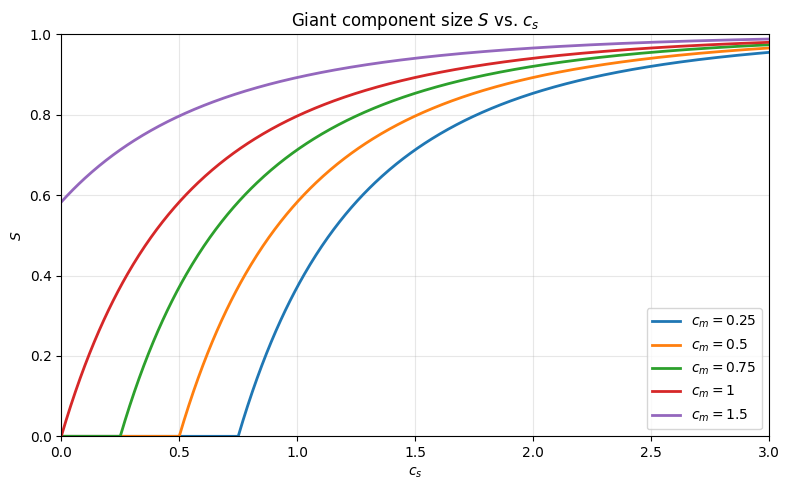

In [4]:
fig, ax = plt.subplots(figsize=(8, 5))

for cm in cm_values:
    S = np.array([giant_component(cs + cm) for cs in cs_values])
    ax.plot(cs_values, S, lw=2, label=fr"$c_m = {cm}$")

ax.set_xlabel(r"$c_s$")
ax.set_ylabel(r"$S$")
ax.set_title(r"Giant component size $S$ vs. $c_s$")
ax.set_xlim(0, 3)
ax.set_ylim(0, 1)
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

## Interactive plots with sliders

Requires `ipywidgets` (works in Jupyter Notebook/Lab, VS Code and Colab). 

**1. $S$ vs. $c_s$**, with $c_m$ as a slider.

In [5]:
import ipywidgets as widgets
from ipywidgets import interact, FloatSlider

def plot_S_vs_cs(cm=0.5):
    S = np.array([giant_component(cs + cm) for cs in cs_values])
    fig, ax = plt.subplots(figsize=(7, 4.5))
    ax.plot(cs_values, S, lw=2, color="tab:blue")
    ax.set_xlabel(r"$c_s$")
    ax.set_ylabel(r"$S$")
    ax.set_title(fr"$S$ vs. $c_s$  ($c_m = {cm:.2f}$)")
    ax.set_xlim(0, 3)
    ax.set_ylim(0, 1)
    ax.grid(alpha=0.3)
    plt.show()

interact(plot_S_vs_cs,
         cm=FloatSlider(value=0.5, min=0, max=3, step=0.05,
                        description=r"c_m", continuous_update=False));

interactive(children=(FloatSlider(value=0.5, continuous_update=False, description='c_m', max=3.0, step=0.05), …

**2. $S$ vs. $c_m$**, with $c_s$ as a slider.

In [6]:
cm_axis = np.linspace(0, 3, 601)

def plot_S_vs_cm(cs=0.5):
    S = np.array([giant_component(cs + cm) for cm in cm_axis])
    fig, ax = plt.subplots(figsize=(7, 4.5))
    ax.plot(cm_axis, S, lw=2, color="tab:red")
    ax.set_xlabel(r"$c_m$")
    ax.set_ylabel(r"$S$")
    ax.set_title(fr"$S$ vs. $c_m$  ($c_s = {cs:.2f}$)")
    ax.set_xlim(0, 3)
    ax.set_ylim(0, 1)
    ax.grid(alpha=0.3)
    plt.show()

interact(plot_S_vs_cm,
         cs=FloatSlider(value=0.5, min=0, max=3, step=0.05,
                        description=r"$c_s$", continuous_update=False));

interactive(children=(FloatSlider(value=0.5, continuous_update=False, description='$c_s$', max=3.0, step=0.05)…